Simulating: 100%|██████████| 20/20 [02:48<00:00,  8.44s/it]


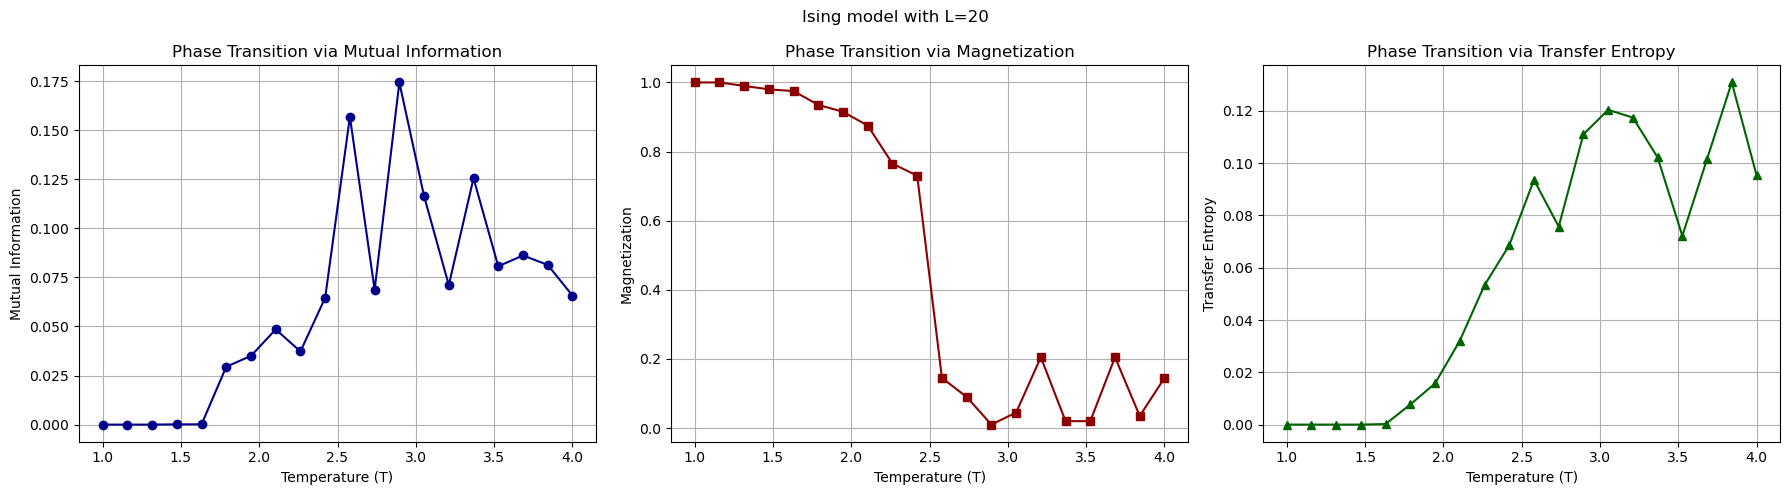

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
from tqdm import tqdm
from collections import Counter

# Parameters
L = 20               # Lattice size (LxL)
n_steps = 2000       # Monte Carlo steps per temperature
temps = np.linspace(1.0, 4.0, 20)  # Temperature range

# Initialize lattice
def init_lattice(L):
    return np.random.choice([-1, 1], size=(L, L))

# Compute energy of a spin
def delta_energy(lattice, x, y):
    spin = lattice[x, y]
    neighbors = lattice[(x+1)%L, y] + lattice[(x-1)%L, y] + \
                lattice[x, (y+1)%L] + lattice[x, (y-1)%L]
    return 2 * spin * neighbors

# Metropolis update
def metropolis(lattice, T):
    for _ in range(L*L):
        x, y = np.random.randint(0, L, 2)
        dE = delta_energy(lattice, x, y)
        if dE < 0 or np.random.rand() < np.exp(-dE / T):
            lattice[x, y] *= -1

# Mutual information between two rows
def mutual_info_rows(lattice):
    mi_total = 0
    for i in range(L - 1):
        row1 = ((lattice[i] + 1) // 2).astype(int)
        row2 = ((lattice[i+1] + 1) // 2).astype(int)
        mi_total += mutual_info_score(row1, row2)
    return mi_total / (L - 1)

# Magnetization per spin
def magnetization(lattice):
    return np.abs(np.sum(lattice)) / (L * L)

# Estimate transfer entropy (simple binary transfer entropy from row to same row in next step)
def transfer_entropy_binary(prev, curr):
    prev = ((prev + 1) // 2).astype(int)
    curr = ((curr + 1) // 2).astype(int)
    
    triplets = [(x1, x2, y) for x1, x2, y in zip(prev[:-1], prev[1:], curr[1:])]
    joint_counts = Counter(triplets)
    cond_counts = Counter((x1, x2) for x1, x2, y in triplets)
    x2y_counts = Counter((x2, y) for x1, x2, y in triplets)
    x2_counts = Counter(x2 for x1, x2, y in triplets)

    te = 0.0
    for (x1, x2, y), p_joint in joint_counts.items():
        p_joint /= len(triplets)
        p_cond = cond_counts[(x1, x2)] / len(triplets)
        p_x2y = x2y_counts[(x2, y)] / len(triplets)
        p_x2 = x2_counts[x2] / len(triplets)

        if p_joint > 0 and p_cond > 0 and p_x2y > 0 and p_x2 > 0:
            te += p_joint * np.log2((p_joint * p_x2) / (p_cond * p_x2y))
    return te

# Run simulation
mi_values = []
magnetization_values = []
transfer_entropy_values = []

for T in tqdm(temps, desc="Simulating"):
    lattice = init_lattice(L)

    # Equilibrate
    for _ in range(n_steps):
        metropolis(lattice, T)
    
    # Make a copy to observe temporal change
    lattice_prev = np.copy(lattice)
    metropolis(lattice, T)
    lattice_curr = np.copy(lattice)

    # Measure quantities
    mi = mutual_info_rows(lattice_curr)
    m = magnetization(lattice_curr)
    te_total = 0
    for row_prev, row_curr in zip(lattice_prev, lattice_curr):
        te_total += transfer_entropy_binary(row_prev, row_curr)
    te_avg = te_total / L

    mi_values.append(mi)
    magnetization_values.append(m)
    transfer_entropy_values.append(te_avg)

# Plot all three
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Mutual Information
axs[0].plot(temps, mi_values, marker='o', color='darkblue')
axs[0].set_xlabel("Temperature (T)")
axs[0].set_ylabel("Mutual Information")
# axs[0].set_title("Phase Transition via Mutual Information")
axs[0].grid(True)

# Magnetization
axs[1].plot(temps, magnetization_values, marker='s', color='darkred')
axs[1].set_xlabel("Temperature (T)")
axs[1].set_ylabel("Magnetization")
# axs[1].set_title("Phase Transition via Magnetization")
axs[1].grid(True)

# Transfer Entropy
axs[2].plot(temps, transfer_entropy_values, marker='^', color='darkgreen')
axs[2].set_xlabel("Temperature (T)")
axs[2].set_ylabel("Transfer Entropy")
# axs[2].set_title("Phase Transition via Transfer Entropy")
axs[2].grid(True)

plt.suptitle('Ising model with L=20')
plt.tight_layout()
plt.show()

Simulating Kuramoto: 100%|██████████| 20/20 [01:45<00:00,  5.26s/it]


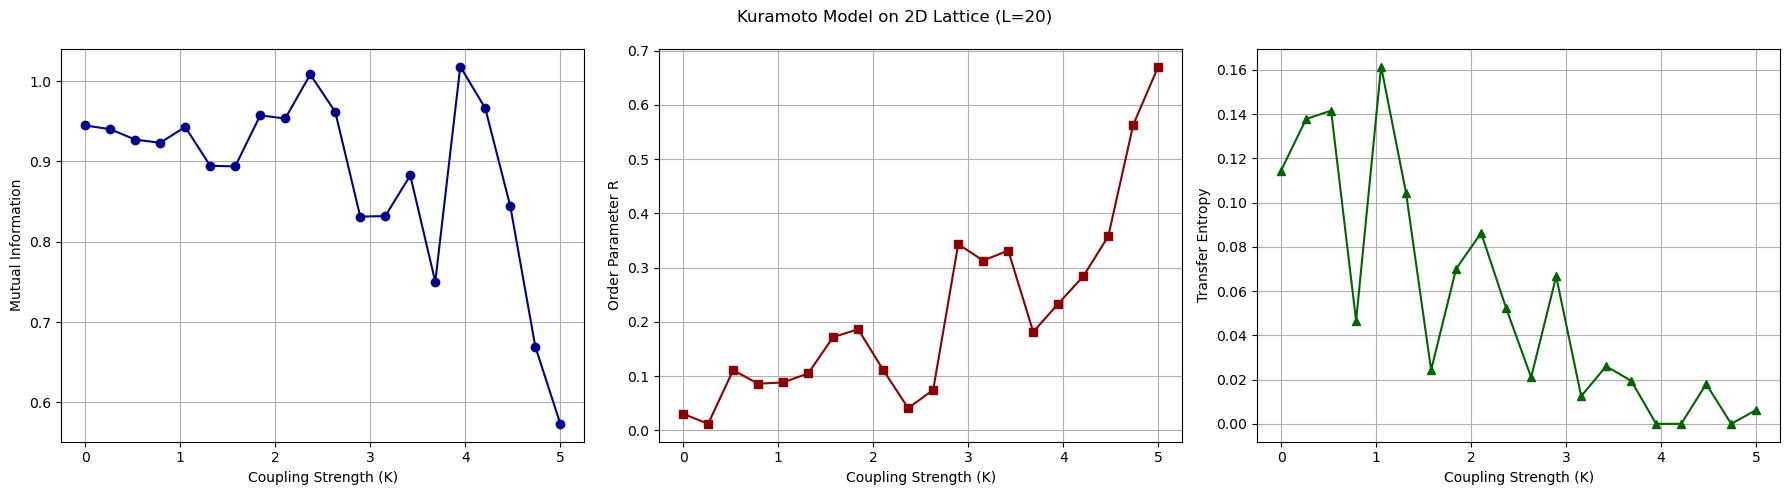

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
from tqdm import tqdm
from collections import Counter

# Parameters
L = 20                # Lattice size (LxL)
n_steps = 2000        # Time steps
K_vals = np.linspace(0.0, 5.0, 20)  # Coupling strengths (analogous to 1/T)

# Initialize lattice: random phases [-π, π]
def init_lattice(L):
    return np.random.uniform(-np.pi, np.pi, size=(L, L))

# Natural frequencies (can be all zero or drawn from distribution)
def init_frequencies(L):
    return np.random.normal(0, 1, size=(L, L))

# Kuramoto update (Euler integration)
def kuramoto_step(theta, omega, K, dt=0.05):
    new_theta = np.copy(theta)
    for x in range(L):
        for y in range(L):
            neighbors = [
                theta[(x+1)%L, y],
                theta[(x-1)%L, y],
                theta[x, (y+1)%L],
                theta[x, (y-1)%L]
            ]
            coupling = np.sum(np.sin(np.array(neighbors) - theta[x, y]))
            new_theta[x, y] += dt * (omega[x, y] + (K / 4.0) * coupling)
    return new_theta % (2 * np.pi)  # Keep in [0, 2π)

# Order parameter (Kuramoto synchronization index)
def order_parameter(theta):
    return np.abs(np.mean(np.exp(1j * theta)))

# Discretize phases to 8 bins for MI/TE
def discretize_phases(theta, bins=8):
    return np.digitize(theta, np.linspace(0, 2 * np.pi, bins, endpoint=False))

# Mutual information between rows
def mutual_info_rows(theta_discrete):
    mi_total = 0
    for i in range(L - 1):
        row1 = theta_discrete[i]
        row2 = theta_discrete[i+1]
        mi_total += mutual_info_score(row1, row2)
    return mi_total / (L - 1)

# Transfer entropy (as before, now on discretized phases)
def transfer_entropy_discrete(prev, curr):
    triplets = [(x1, x2, y) for x1, x2, y in zip(prev[:-1], prev[1:], curr[1:])]
    joint_counts = Counter(triplets)
    cond_counts = Counter((x1, x2) for x1, x2, y in triplets)
    x2y_counts = Counter((x2, y) for x1, x2, y in triplets)
    x2_counts = Counter(x2 for x1, x2, y in triplets)

    te = 0.0
    for (x1, x2, y), p_joint in joint_counts.items():
        p_joint /= len(triplets)
        p_cond = cond_counts[(x1, x2)] / len(triplets)
        p_x2y = x2y_counts[(x2, y)] / len(triplets)
        p_x2 = x2_counts[x2] / len(triplets)

        if p_joint > 0 and p_cond > 0 and p_x2y > 0 and p_x2 > 0:
            te += p_joint * np.log2((p_joint * p_x2) / (p_cond * p_x2y))
    return te

# Simulation loop
mi_values = []
order_param_values = []
transfer_entropy_values = []

for K in tqdm(K_vals, desc="Simulating Kuramoto"):
    theta = init_lattice(L)
    omega = init_frequencies(L)

    # Evolve system
    for _ in range(n_steps):
        theta = kuramoto_step(theta, omega, K)

    theta_prev = np.copy(theta)
    theta = kuramoto_step(theta, omega, K)
    theta_curr = np.copy(theta)

    # Discretize phases
    theta_prev_disc = discretize_phases(theta_prev)
    theta_curr_disc = discretize_phases(theta_curr)

    # Measurements
    mi = mutual_info_rows(theta_curr_disc)
    r = order_parameter(theta_curr)
    te_total = 0
    for row_prev, row_curr in zip(theta_prev_disc, theta_curr_disc):
        te_total += transfer_entropy_discrete(row_prev, row_curr)
    te_avg = te_total / L

    mi_values.append(mi)
    order_param_values.append(r)
    transfer_entropy_values.append(te_avg)

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(K_vals, mi_values, marker='o', color='darkblue')
axs[0].set_xlabel("Coupling Strength (K)")
axs[0].set_ylabel("Mutual Information")
axs[0].grid(True)

axs[1].plot(K_vals, order_param_values, marker='s', color='darkred')
axs[1].set_xlabel("Coupling Strength (K)")
axs[1].set_ylabel("Order Parameter R")
axs[1].grid(True)

axs[2].plot(K_vals, transfer_entropy_values, marker='^', color='darkgreen')
axs[2].set_xlabel("Coupling Strength (K)")
axs[2].set_ylabel("Transfer Entropy")
axs[2].grid(True)

plt.suptitle('Kuramoto Model on 2D Lattice (L=20)')
plt.tight_layout()
plt.show()

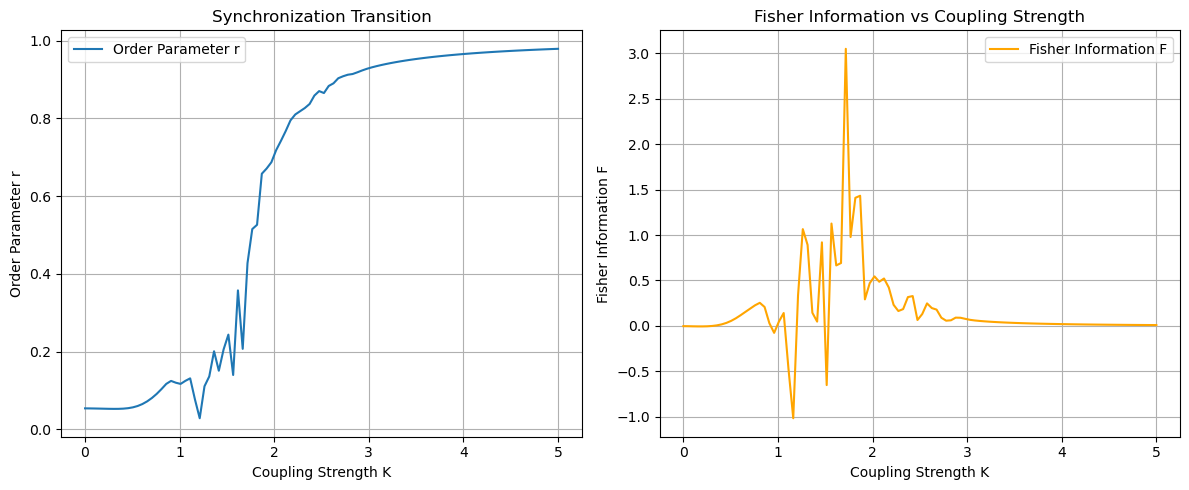

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.stats import norm

# Parameters
N = 400  # Number of oscillators
K_values = np.linspace(0, 5, 100)  # Coupling strengths
T = 100  # Total time
dt = 0.1  # Time step
time = np.arange(0, T, dt)

# Natural frequencies drawn from a normal distribution
np.random.seed(0)
omega = np.random.normal(0, 1, N)

# Function to compute the derivative
def kuramoto_derivative(theta, t, K, omega):
    theta_diff = theta[:, None] - theta
    coupling = np.sum(np.sin(-theta_diff), axis=1)
    return omega + (K / N) * coupling

# Function to compute the order parameter
def compute_order_parameter(theta):
    return np.abs(np.sum(np.exp(1j * theta)) / N)

# Arrays to store results
r_values = []

# Initial condition
theta0 = np.random.uniform(0, 2 * np.pi, N)

for K in K_values:
    # Integrate the Kuramoto model
    theta = odeint(kuramoto_derivative, theta0, time, args=(K, omega))
    # Compute the order parameter at the final time
    r = compute_order_parameter(theta[-1])
    r_values.append(r)

# Compute the derivative of r with respect to K (Fisher Information)
r_values = np.array(r_values)
F_values = np.gradient(r_values, K_values)

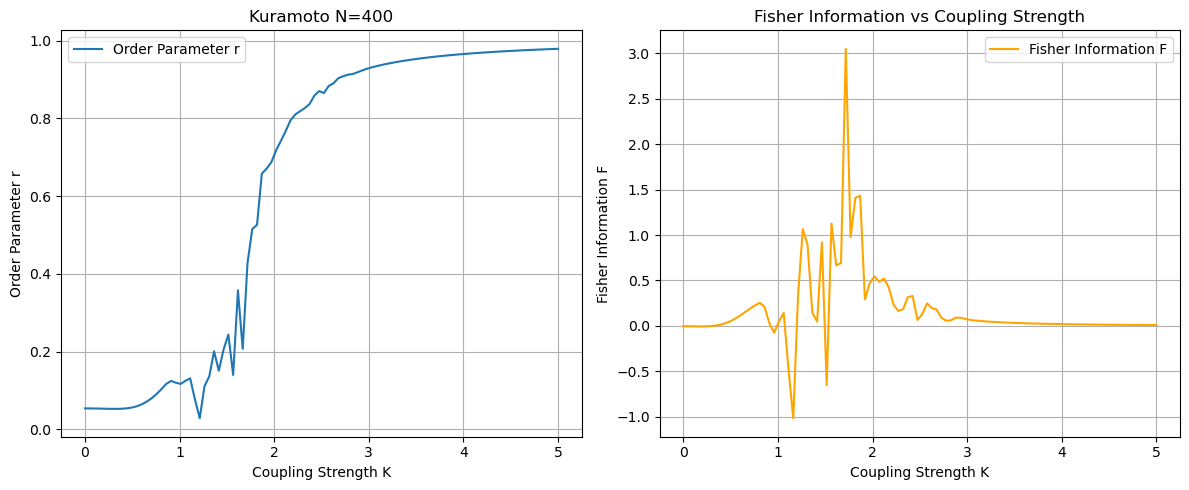

In [2]:
# Plotting
plt.figure(figsize=(12, 5))

# Order parameter plot
plt.subplot(1, 2, 1)
plt.plot(K_values, r_values, label='Order Parameter r')
plt.xlabel('Coupling Strength K')
plt.ylabel('Order Parameter r')
plt.title('Kuramoto N=400')
plt.grid(True)
plt.legend()

# Fisher Information plot
plt.subplot(1, 2, 2)
plt.plot(K_values, F_values, label='Fisher Information F', color='orange')
plt.xlabel('Coupling Strength K')
plt.ylabel('Fisher Information F')
plt.title('Fisher Information vs Coupling Strength')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

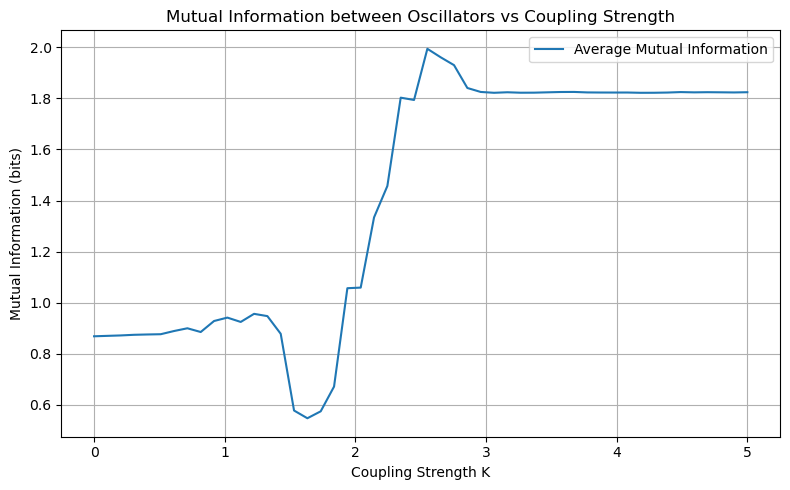

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from sklearn.metrics import mutual_info_score

# Parameters
N = 100  # Reduced for computational efficiency
K_values = np.linspace(0, 5, 50)  # Coupling strengths
T = 100  # Total time
dt = 0.1  # Time step
time = np.arange(0, T, dt)
n_bins = 20  # Number of bins for phase histograms

# Natural frequencies
np.random.seed(0)
omega = np.random.normal(0, 1, N)

# Kuramoto derivative function
def kuramoto_derivative(theta, t, K, omega):
    theta_diff = theta[:, None] - theta
    coupling = np.sum(np.sin(-theta_diff), axis=1)
    return omega + (K / N) * coupling

# Mutual information computation for binned time series
def compute_mutual_information_matrix(theta_time_series, n_bins=20):
    N = theta_time_series.shape[1]
    binned_data = np.floor(n_bins * (theta_time_series % (2 * np.pi)) / (2 * np.pi)).astype(int)

    mi_total = 0
    count = 0
    for i in range(N):
        for j in range(i+1, N):
            mi = mutual_info_score(binned_data[:, i], binned_data[:, j])
            mi_total += mi
            count += 1
    return mi_total / count

# Store mutual information values
MI_values = []

# Initial condition
theta0 = np.random.uniform(0, 2 * np.pi, N)

for K in K_values:
    # Integrate the system
    theta = odeint(kuramoto_derivative, theta0, time, args=(K, omega))
    
    # Remove transients by taking the second half of the time series
    theta_reduced = theta[len(theta)//2:]
    
    # Compute mean pairwise mutual information
    mi_avg = compute_mutual_information_matrix(theta_reduced, n_bins)
    MI_values.append(mi_avg)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(K_values, MI_values, label='Average Mutual Information')
plt.xlabel('Coupling Strength K')
plt.ylabel('Mutual Information (bits)')
plt.title('Mutual Information between Oscillators vs Coupling Strength')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Simulating Vicsek model: 100%|██████████| 20/20 [13:15<00:00, 39.76s/it]


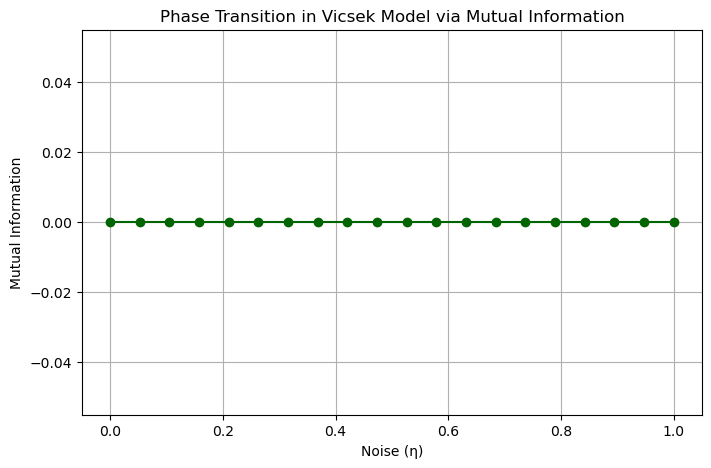

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
from tqdm import tqdm

# Parameters
N = 300                  # Number of particles
L = 10.0                 # Box size
v = 0.03                 # Particle speed
r = 1.0                  # Interaction radius
n_steps = 200            # Time steps for each noise value
etas = np.linspace(0, 1.0, 20)  # Noise levels

# Initialize particles
def init_particles(N, L):
    positions = np.random.rand(N, 2) * L
    angles = np.random.rand(N) * 2 * np.pi
    return positions, angles

# Update positions and directions
def update(positions, angles, eta, L, v, r):
    N = len(positions)
    new_angles = np.zeros_like(angles)

    for i in range(N):
        # Find neighbors
        dx = positions[:, 0] - positions[i, 0]
        dy = positions[:, 1] - positions[i, 1]

        # Periodic boundary conditions
        dx = dx - L * np.round(dx / L)
        dy = dy - L * np.round(dy / L)

        dist2 = dx**2 + dy**2
        neighbors = dist2 < r**2

        # Average angle
        sin_sum = np.sum(np.sin(angles[neighbors]))
        cos_sum = np.sum(np.cos(angles[neighbors]))
        avg_angle = np.arctan2(sin_sum, cos_sum)

        # Add noise
        new_angles[i] = avg_angle + eta * (np.random.rand() - 0.5) * 2 * np.pi

    # Update positions
    positions[:, 0] += v * np.cos(new_angles)
    positions[:, 1] += v * np.sin(new_angles)

    # Periodic boundary conditions
    positions %= L

    return positions, new_angles

# Compute mutual information between heading angles of neighboring particles
def compute_mutual_info(angles):
    # Discretize angles into bins
    bins = 20
    discretized = np.floor(angles / (2 * np.pi) * bins).astype(int)

    # Estimate MI between all pairs (symmetric matrix, MI[i,j])
    N = len(discretized)
    mi_total = 0
    count = 0
    for i in range(N):
        for j in range(i + 1, N):
            mi = mutual_info_score([discretized[i]], [discretized[j]])
            mi_total += mi
            count += 1
    return mi_total / count if count > 0 else 0

# Run simulation
mi_values = []

for eta in tqdm(etas, desc="Simulating Vicsek model"):
    positions, angles = init_particles(N, L)

    # Evolve system
    for step in range(n_steps):
        positions, angles = update(positions, angles, eta, L, v, r)

    # Compute MI at the end
    mi = compute_mutual_info(angles)
    mi_values.append(mi)

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(etas, mi_values, marker='o', color='darkgreen')
plt.xlabel("Noise (η)")
plt.ylabel("Mutual Information")
plt.title("Phase Transition in Vicsek Model via Mutual Information")
plt.grid(True)
plt.show()